# 使用PyTorch实现 Conv1D 和 LSTM 时序预测

本 Notebook 将带你学习如何使用 PyTorch 对**带噪声的正弦函数**进行时序预测。

## 学习目标
1. 生成带噪声的合成时序数据
2. 使用 **Conv1D**（一维卷积）进行时序预测
3. 使用 **LSTM**（长短期记忆网络）进行时序预测
4. 比较两种模型的效果

In [1]:
# 1. 导入必要库

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

import numpy as np

# 使用 %matplotlib inline 避免 Qt GUI 导致的 Kernel 崩溃
%matplotlib inline
import matplotlib.pyplot as plt

# 设置中文字体，解决中文显示问题
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error

# 设置随机种子，保证结果可重复
np.random.seed(42)
torch.manual_seed(42)

# 检查是否有CUDA可用
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

使用设备: cpu


## 2. 生成带噪声的正弦函数数据

生成一段带高斯噪声的正弦波信号，用于后续的时序预测任务。纯净信号为 $\sin(t)$，噪声服从 $\mathcal{N}(0, 0.2^2)$。

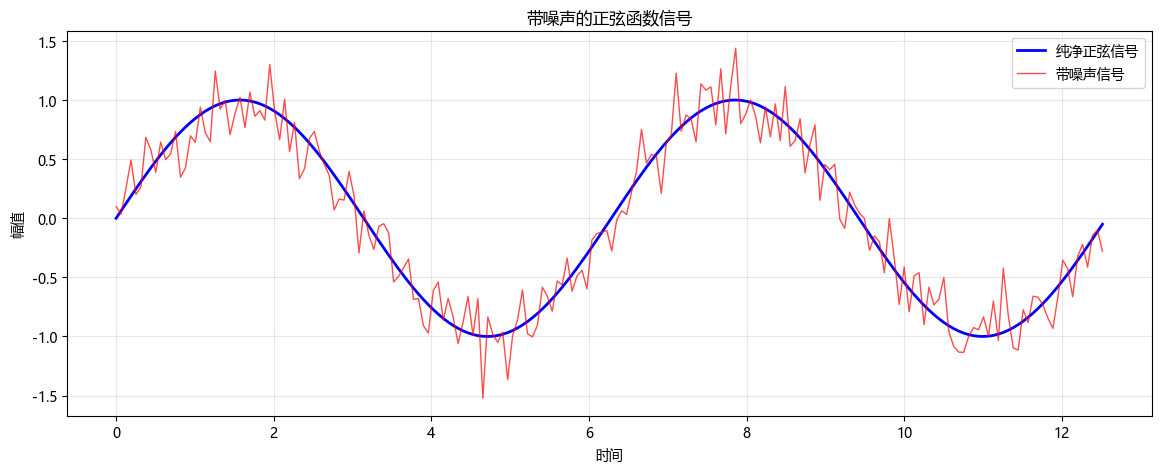

信号长度: 1000
噪声标准差: 0.2


In [2]:
# 2. 生成带噪声的正弦函数数据

seq_length = 1000      # 总数据点数
time = np.linspace(0, 20 * np.pi, seq_length)  # 时间轴

# 生成纯净的正弦信号
clean_signal = np.sin(time)

# 生成带噪声的信号（添加高斯噪声）
noise_std = 0.2
noise = np.random.normal(0, noise_std, size=time.shape)
noisy_signal = clean_signal + noise

# 可视化原始信号与带噪声信号
plt.figure(figsize=(14, 5))
plt.plot(time[:200], clean_signal[:200], 'b-', label='纯净正弦信号', linewidth=2)
plt.plot(time[:200], noisy_signal[:200], 'r-', alpha=0.7, label='带噪声信号', linewidth=1)
plt.legend()
plt.xlabel('时间')
plt.ylabel('幅值')
plt.title('带噪声的正弦函数信号')
plt.grid(True, alpha=0.3)
plt.show()

print(f"信号长度: {len(noisy_signal)}")
print(f"噪声标准差: {noise_std}")

## 3. 数据预处理与创建数据集

使用**滑动窗口（Sliding Window）**将时序数据转换为监督学习格式：
- 用过去 `window_size` 个时间点的数据作为特征（X）
- 预测下一个时间点的数据作为标签（y）

In [3]:
# 3. 数据预处理与创建数据集

def create_sequences(data, window_size):
    """将时序数据转换为 (样本数, 窗口大小) 的监督学习格式"""
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)


window_size = 20  # 用过去20个点预测下1个点
X_all, y_all = create_sequences(noisy_signal, window_size)
print(f"数据集形状: X = {X_all.shape}, y = {y_all.shape}")

# 划分训练集和测试集（80% 训练，20% 测试）
train_ratio = 0.8
train_size = int(len(X_all) * train_ratio)

X_train = X_all[:train_size]
y_train = y_all[:train_size]
X_test  = X_all[train_size:]
y_test  = y_all[train_size:]

print(f"训练集: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"测试集: X_test  = {X_test.shape}, y_test  = {y_test.shape}")

# 转换为 PyTorch Tensor（Conv1D 需要 (batch, channels, seq_len) 格式）
X_train_t = torch.FloatTensor(X_train).unsqueeze(1).to(device)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)
X_test_t  = torch.FloatTensor(X_test).unsqueeze(1).to(device)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1).to(device)

# 创建 DataLoader
batch_size = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print("DataLoader 创建完成！")

数据集形状: X = (980, 20), y = (980,)
训练集: X_train = (784, 20), y_train = (784,)
测试集: X_test  = (196, 20), y_test  = (196,)
DataLoader 创建完成！


## 4. 定义 Conv1D 模型

Conv1D 通过一维卷积核在时间维度上滑动提取局部特征：
- `Conv1d(1, 16, 3)`：输入通道1，输出通道16，卷积核大小3
- 卷积后序列长度 = 输入长度 - kernel_size + 1 = 20 - 3 + 1 = 18
- 展平后通过全连接层映射到1个输出值

In [4]:
# 4. 定义 Conv1D 模型

class Conv1DModel(nn.Module):
    def __init__(self, input_size, out_channels=16, kernel_size=3):
        super(Conv1DModel, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=out_channels, kernel_size=kernel_size)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        conv_output_len = input_size - kernel_size + 1
        self.fc = nn.Linear(out_channels * conv_output_len, 1)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x


# 创建 Conv1D 模型
conv_model = Conv1DModel(input_size=window_size).to(device)
print(conv_model)

Conv1DModel(
  (conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=288, out_features=1, bias=True)
)


## 5. 训练 Conv1D 模型

使用 **MSE损失** 和 **Adam优化器** 训练 100 个 epoch。训练过程包括：前向传播 → 计算损失 → 反向传播 → 参数更新。

开始训练 Conv1D 模型...
Conv1D - Epoch [20/100], Loss: 0.046591
Conv1D - Epoch [40/100], Loss: 0.041250
Conv1D - Epoch [60/100], Loss: 0.042976
Conv1D - Epoch [80/100], Loss: 0.040517
Conv1D - Epoch [100/100], Loss: 0.042336


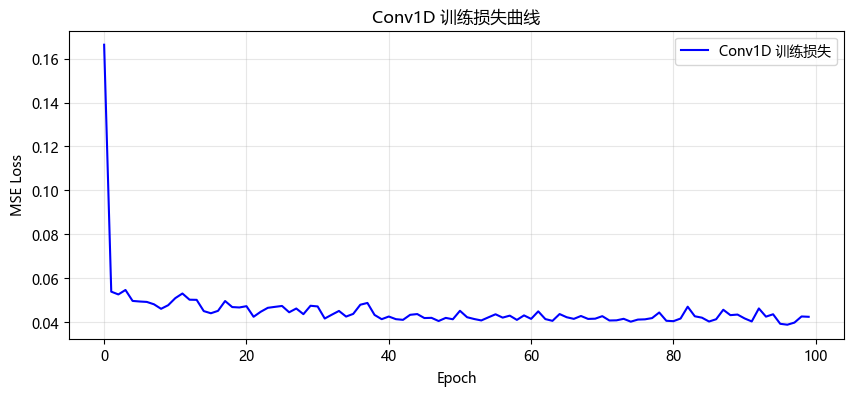

In [5]:
# 5. 训练 Conv1D 模型

def train_model(model, train_loader, epochs, lr=0.001, model_name="Model"):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    model.train()
    history = []
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        history.append(avg_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f'{model_name} - Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')
    
    return history


# 训练 Conv1D 模型
print("开始训练 Conv1D 模型...")
conv_history = train_model(conv_model, train_loader, epochs=100, lr=0.01, model_name="Conv1D")

# 绘制训练损失曲线
plt.figure(figsize=(10, 4))
plt.plot(conv_history, 'b-', label='Conv1D 训练损失')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Conv1D 训练损失曲线')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Conv1D 模型预测与评估

用训练好的 Conv1D 模型对测试集进行预测，计算 MSE 并可视化预测结果与实际值的对比。

Conv1D 测试集 MSE: 0.067443


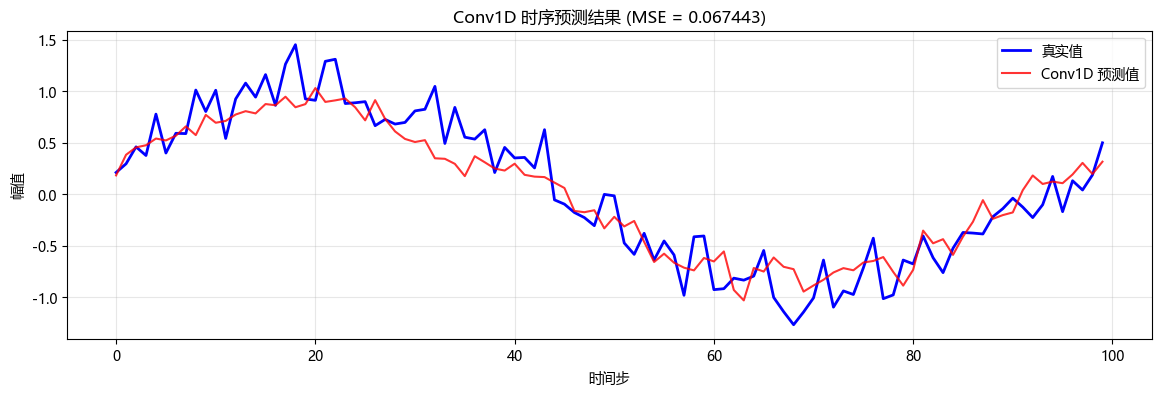

In [6]:
# Conv1D 模型预测与评估

conv_model.eval()
with torch.no_grad():
    conv_predictions = conv_model(X_test_t).cpu().numpy()

conv_pred_flat = conv_predictions.flatten()
y_test_flat = y_test.flatten()

# 计算 Conv1D 的 MSE
conv_mse = mean_squared_error(y_test_flat, conv_pred_flat)
print(f"Conv1D 测试集 MSE: {conv_mse:.6f}")

# 可视化 Conv1D 预测结果（显示前100个测试点）
plt.figure(figsize=(14, 4))
plt.plot(y_test_flat[:100], 'b-', label='真实值', linewidth=2)
plt.plot(conv_pred_flat[:100], 'r-', label='Conv1D 预测值', linewidth=1.5, alpha=0.8)
plt.legend()
plt.xlabel('时间步')
plt.ylabel('幅值')
plt.title(f'Conv1D 时序预测结果 (MSE = {conv_mse:.6f})')
plt.grid(True, alpha=0.3)
plt.show()

## 6. 定义 LSTM 模型

LSTM 通过门控机制（输入门、遗忘门、输出门）捕捉长距离时序依赖：
- `LSTM(1, 64, 2, batch_first=True)`：输入特征1维，隐藏层64维，堆叠2层
- 取最后一个时间步的隐藏状态，通过全连接层映射到1个输出

In [7]:
# 6. 定义 LSTM 模型

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # 输入 x: (batch, window_size) -> (batch, window_size, 1)
        x = x.unsqueeze(-1)
        lstm_out, (h_n, c_n) = self.lstm(x)
        last_out = lstm_out[:, -1, :]  # 取最后一个时间步
        output = self.fc(last_out)
        return output


# 创建 LSTM 专用的 DataLoader（输入形状为 (batch, window_size)）
X_train_lstm = torch.FloatTensor(X_train).to(device)
y_train_lstm = torch.FloatTensor(y_train).unsqueeze(1).to(device)
X_test_lstm  = torch.FloatTensor(X_test).to(device)
y_test_lstm  = torch.FloatTensor(y_test).unsqueeze(1).to(device)

train_loader_lstm = DataLoader(TensorDataset(X_train_lstm, y_train_lstm), 
                               batch_size=batch_size, shuffle=True)
test_loader_lstm  = DataLoader(TensorDataset(X_test_lstm, y_test_lstm), 
                               batch_size=batch_size, shuffle=False)

lstm_model = LSTMModel(input_size=1, hidden_size=64, num_layers=2).to(device)
print(lstm_model)

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 7. 训练 LSTM 模型

与 Conv1D 相同的训练配置：MSE损失、Adam优化器、100个epoch。观察 LSTM 的收敛情况。

开始训练 LSTM 模型...
LSTM - Epoch [20/100], Loss: 0.051187
LSTM - Epoch [40/100], Loss: 0.047225
LSTM - Epoch [60/100], Loss: 0.045620
LSTM - Epoch [80/100], Loss: 0.042043
LSTM - Epoch [100/100], Loss: 0.036315


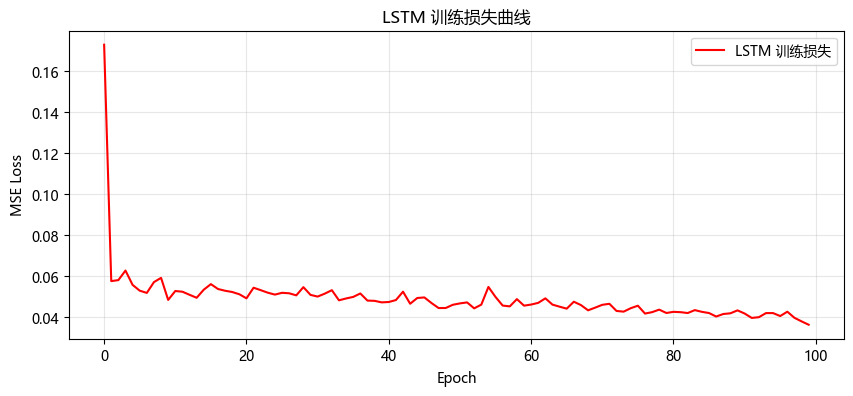

In [8]:
# 7. 训练 LSTM 模型

def train_lstm_model(model, train_loader, epochs, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    model.train()
    history = []
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        history.append(avg_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f'LSTM - Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')
    
    return history


# 训练 LSTM 模型
print("开始训练 LSTM 模型...")
lstm_history = train_lstm_model(lstm_model, train_loader_lstm, epochs=100, lr=0.01)

# 绘制训练损失曲线
plt.figure(figsize=(10, 4))
plt.plot(lstm_history, 'r-', label='LSTM 训练损失')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM 训练损失曲线')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## LSTM 模型预测与评估

用训练好的 LSTM 模型对测试集进行预测，计算 MSE 并与 Conv1D 的结果对比。

LSTM 测试集 MSE: 0.046163


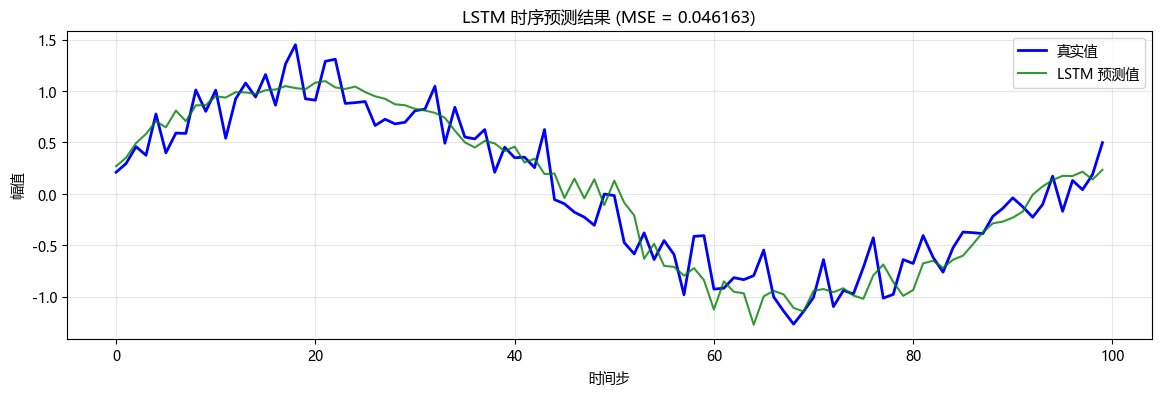

In [9]:
# LSTM 模型预测与评估

lstm_model.eval()
with torch.no_grad():
    lstm_predictions = lstm_model(X_test_lstm).cpu().numpy()

lstm_pred_flat = lstm_predictions.flatten()

# 计算 LSTM 的 MSE
lstm_mse = mean_squared_error(y_test_flat, lstm_pred_flat)
print(f"LSTM 测试集 MSE: {lstm_mse:.6f}")

# 可视化 LSTM 预测结果（显示前100个测试点）
plt.figure(figsize=(14, 4))
plt.plot(y_test_flat[:100], 'b-', label='真实值', linewidth=2)
plt.plot(lstm_pred_flat[:100], 'g-', label='LSTM 预测值', linewidth=1.5, alpha=0.8)
plt.legend()
plt.xlabel('时间步')
plt.ylabel('幅值')
plt.title(f'LSTM 时序预测结果 (MSE = {lstm_mse:.6f})')
plt.grid(True, alpha=0.3)
plt.show()

## 8. 综合对比：Conv1D vs LSTM

对比两种模型在测试集上的 MSE 以及预测曲线的拟合效果。

模型性能对比（MSE - 均方误差）
Conv1D  MSE: 0.067443
LSTM    MSE: 0.046163


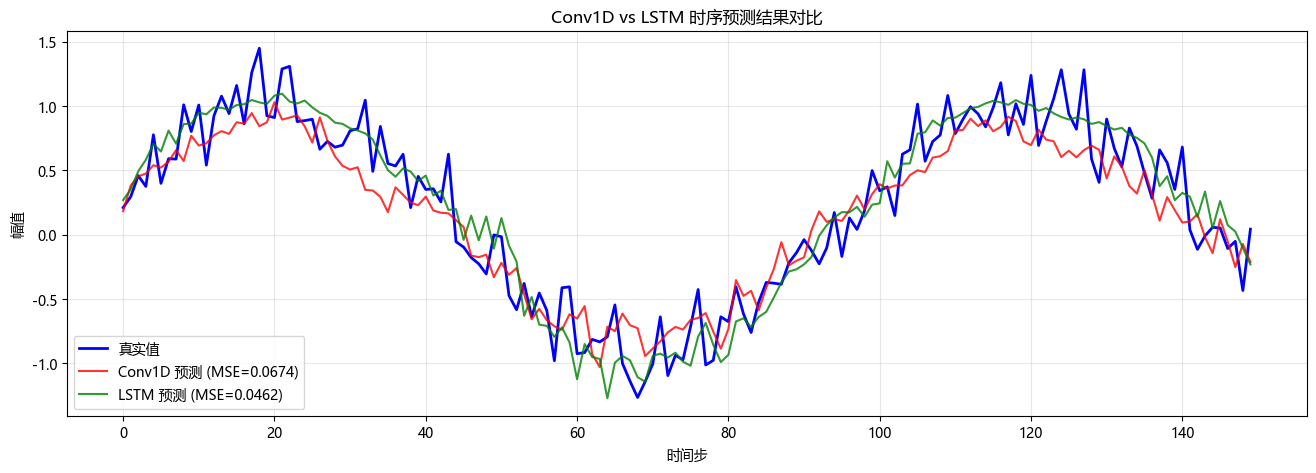

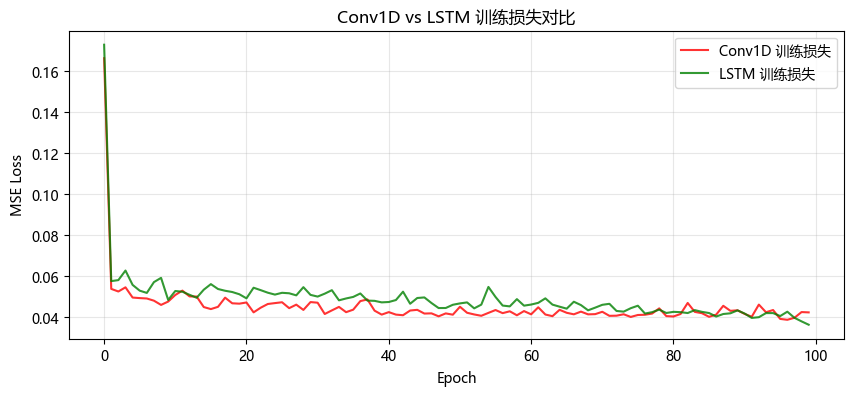

In [10]:
# 8. 综合对比：Conv1D vs LSTM

print(f"{'='*40}")
print(f"模型性能对比（MSE - 均方误差）")
print(f"{'='*40}")
print(f"Conv1D  MSE: {conv_mse:.6f}")
print(f"LSTM    MSE: {lstm_mse:.6f}")
print(f"{'='*40}")

# 绘制三种曲线对比图
plt.figure(figsize=(16, 5))
plt.plot(y_test_flat[:150], 'b-', label='真实值', linewidth=2)
plt.plot(conv_pred_flat[:150], 'r-', label=f'Conv1D 预测 (MSE={conv_mse:.4f})', 
         linewidth=1.5, alpha=0.8)
plt.plot(lstm_pred_flat[:150], 'g-', label=f'LSTM 预测 (MSE={lstm_mse:.4f})', 
         linewidth=1.5, alpha=0.8)
plt.legend()
plt.xlabel('时间步')
plt.ylabel('幅值')
plt.title('Conv1D vs LSTM 时序预测结果对比')
plt.grid(True, alpha=0.3)
plt.show()

# 绘制两种模型的训练损失对比
plt.figure(figsize=(10, 4))
plt.plot(conv_history, 'r-', label='Conv1D 训练损失', alpha=0.8)
plt.plot(lstm_history, 'g-', label='LSTM 训练损失', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Conv1D vs LSTM 训练损失对比')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()